In [12]:
import pandas as pd
from util.load import DataLoader
import matplotlib.pyplot as plt
import os
import numpy as np

In [4]:
dataloader = DataLoader(data_dir="../data")
ticker = "kxhighny"
max_days = 50
full_df = dataloader.load_consolidated_daily_data(
    ticker, max_days=max_days, type_="processed"
)
daily_df = dataloader.load_daily_data(ticker, max_days=max_days, type_="processed")
full_df.drop(columns=["time", "ticker", "trade_id"]).head()

Loading kxhighny for 2025-05-29: 100%|██████████| 50/50 [00:00<00:00, 294.40it/s]


,time_to_strike,count,shift,kalshi_fair,forecast,yes_price,no_price,taker_side,kalshi_strike_delta,forecast_strike_delta,...,strike_m_5.0,strike_m_3.0,strike_m_1.0,strike_p_1.0,strike_p_3.0,strike_p_5.0,entropy,impact,result,outcome
0,136542.267,5,-1.0,51.500,50.5,52,48,1,0.000,-1.0,...,0.0,0.00,52.00,0.0,0.0,0.0,-205.465,47.0,48,1
1,132716.210,29,-3.0,50.703,50.5,31,69,0,1.203,1.0,...,0.0,31.00,46.80,0.0,0.0,0.0,-286.441,30.0,31,0
2,132716.210,27,-3.0,50.684,50.5,29,71,0,1.184,1.0,...,0.0,29.00,42.12,0.0,0.0,0.0,-255.202,28.0,29,0
3,132715.930,56,-1.0,50.631,50.5,34,66,0,-0.869,-1.0,...,0.0,26.10,34.00,0.0,0.0,0.0,-205.033,-65.0,-66,1
4,115792.359,30,3.0,51.118,50.5,6,94,1,-4.382,-5.0,...,0.0,23.49,30.60,0.0,6.0,0.0,-189.581,-5.0,-6,0


In [22]:
implied_deviations = []
entropies = []
for day, df in daily_df.items():
    devs = []
    entropy = []
    for i in range(len(df)):
        dev = df.iloc[i]["kalshi_fair"] - df.iloc[i]["forecast"]
        devs.append(dev)
        entropy.append(df.iloc[i]["entropy"])
    implied_deviations.append(np.mean(devs))
    entropies.append(np.mean(entropy))

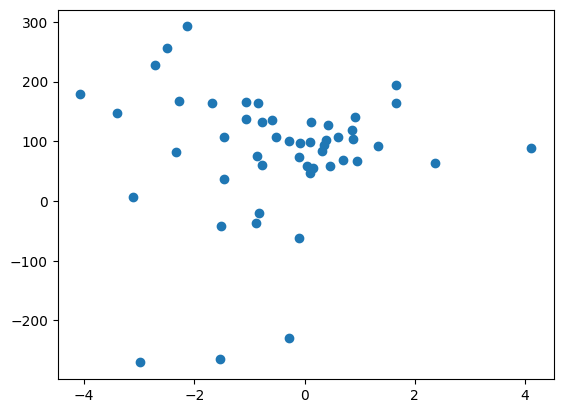

In [23]:
backtest_run = os.listdir("../backtests")[-1]
backtest_df = pd.read_csv(f"../backtests/{backtest_run}")
backtest_df['implied_deviation'] = implied_deviations
backtest_df['entropy'] = entropies

plt.scatter(backtest_df['implied_deviation'], backtest_df['profit'])
plt.show()


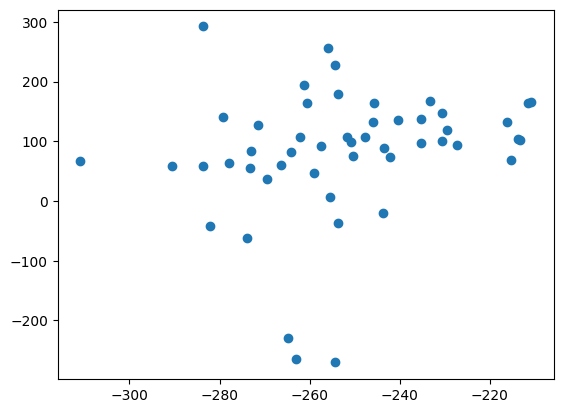

In [24]:
plt.scatter(backtest_df['entropy'], backtest_df['profit'])
plt.show()
